# Pore Masks Notebook

This notebook detects pores in a magnetogram from a 24-hour magnetogram cube. The algorithm consists of the following steps:

1. Open the magnetogram cube and select one of the 1920 frames.
2. Select pixels with values above the 80th percentile, excluding the edges of the magnetogram by restricting the analysis to the region `[150:845]`.
3. Group neighboring pixels that satisfy these conditions into individual regions (pores).
4. Assign a circular mask to each detected region, with an area equivalent to that of the original region.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

import sys
sys.path.append("../codes") # Add this folder to Python's module search path

from pore_detection import (
    load_magnetogram_frame,
    detect_magnetic_regions,
    filter_regions_by_radius
)
print(load_magnetogram_frame)
print(detect_magnetic_regions)
print(filter_regions_by_radius)

<function load_magnetogram_frame at 0x7faeaf01be20>
<function detect_magnetic_regions at 0x7faeaf048540>
<function filter_regions_by_radius at 0x7faeaf048860>


In [2]:
MAG_cube = "../data/2018_08_25/cubes/MAG_24.fits"

mag_frame, header = load_magnetogram_frame(
    MAG_cube,
    frame_number=0
)

regions, labeled_regions, mag_mask, threshold = detect_magnetic_regions(
    mag_frame,
    percentile=80,
    crop=(150, 845)
)

selected_regions = filter_regions_by_radius(
    regions,
    labeled_regions,
    mag_frame,
    min_radius=5
)

Magnetic threshold: 13.19
Number of detected regions: 25942
Maximum equivalent radius: 12.06 pixels
Mean equivalent radius: 0.86 pixels
Standard deviation: 0.63 pixels
Selected regions (r >= 5 px): 102


In [3]:
NFRAMES = 1920
N_REFERENCE_FRAMES = 4

magnetograms_of_reference = []

for n in range(N_REFERENCE_FRAMES):

    frame = n * NFRAMES // N_REFERENCE_FRAMES

    mag_frame, header = load_magnetogram_frame(
        MAG_cube,
        frame_number=frame
    )

    magnetogram_mean = np.nanmean(mag_frame)
    magnetogram_std = np.nanstd(mag_frame)

    magnetograms_of_reference.append({
        "frame": frame,
        "magnetogram": mag_frame,
        "header": header,
        "mean": magnetogram_mean,
        "std": magnetogram_std
    })

    print(
        f"Frame {frame:4d} | "
        f"Mean = {magnetogram_mean:.2f} G | "
        f"Std = {magnetogram_std:.2f} G"
    )

Frame    0 | Mean = -0.18 G | Std = 16.91 G
Frame  480 | Mean = -0.16 G | Std = 16.95 G
Frame  960 | Mean = -0.16 G | Std = 15.99 G
Frame 1440 | Mean = -0.26 G | Std = 15.75 G


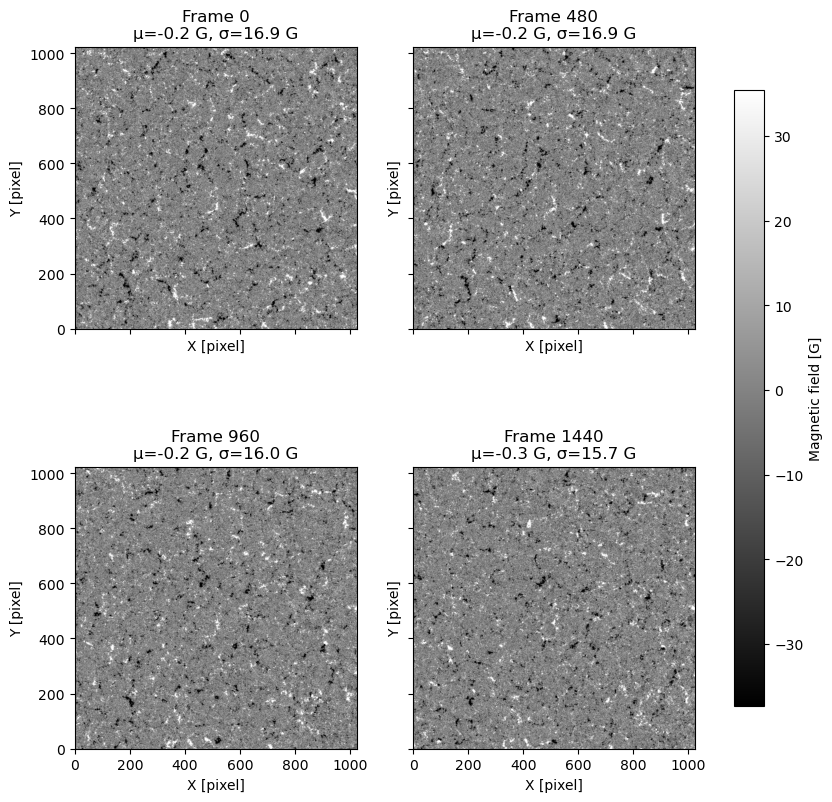

In [4]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 10),
    sharex=True,
    sharey=True
)

# Common color scale for all four magnetograms
all_values = np.concatenate([
    ref["magnetogram"][np.isfinite(ref["magnetogram"])].ravel()
    for ref in magnetograms_of_reference
])

vmin, vmax = np.percentile(all_values, [1, 99])

for ax, ref in zip(axes.flat, magnetograms_of_reference):

    im = ax.imshow(
        ref["magnetogram"],
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(
        f'Frame {ref["frame"]}\n'
        f'μ={ref["mean"]:.1f} G, σ={ref["std"]:.1f} G'
    )

    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")

fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    label="Magnetic field [G]",
    shrink=0.8
)

plt.show()

In [5]:
for ref in magnetograms_of_reference:

    # Get reference magnetogram
    mag_frame = ref["magnetogram"]

    # Detect magnetic regions
    regions, labeled_regions, mag_mask, threshold = detect_magnetic_regions(
        mag_frame,
        percentile=80,
        crop=(150, 845)
    )

    # Select regions according to equivalent radius
    selected_regions = filter_regions_by_radius(
        regions,
        labeled_regions,
        mag_frame,
        min_radius=5
    )

    # Store detection results

    # Properties of all detected connected magnetic regions
    ref["regions"] = regions

    # Labeled image assigning a unique integer ID to each connected magnetic region
    ref["labeled_regions"] = labeled_regions

    # Boolean mask identifying pixels that satisfy the magnetic-field criterion
    ref["mag_mask"] = mag_mask

    # Magnetic-field value corresponding to the selected percentile threshold
    ref["threshold"] = threshold

    # Regions that satisfy the minimum equivalent-radius criterion
    ref["selected_regions"] = selected_regions

Magnetic threshold: 13.19
Number of detected regions: 25942
Maximum equivalent radius: 12.06 pixels
Mean equivalent radius: 0.86 pixels
Standard deviation: 0.63 pixels
Selected regions (r >= 5 px): 102
Magnetic threshold: 13.29
Number of detected regions: 26349
Maximum equivalent radius: 13.27 pixels
Mean equivalent radius: 0.86 pixels
Standard deviation: 0.62 pixels
Selected regions (r >= 5 px): 93
Magnetic threshold: 13.16
Number of detected regions: 26209
Maximum equivalent radius: 14.14 pixels
Mean equivalent radius: 0.87 pixels
Standard deviation: 0.63 pixels
Selected regions (r >= 5 px): 106
Magnetic threshold: 13.32
Number of detected regions: 26845
Maximum equivalent radius: 14.03 pixels
Mean equivalent radius: 0.86 pixels
Standard deviation: 0.61 pixels
Selected regions (r >= 5 px): 85


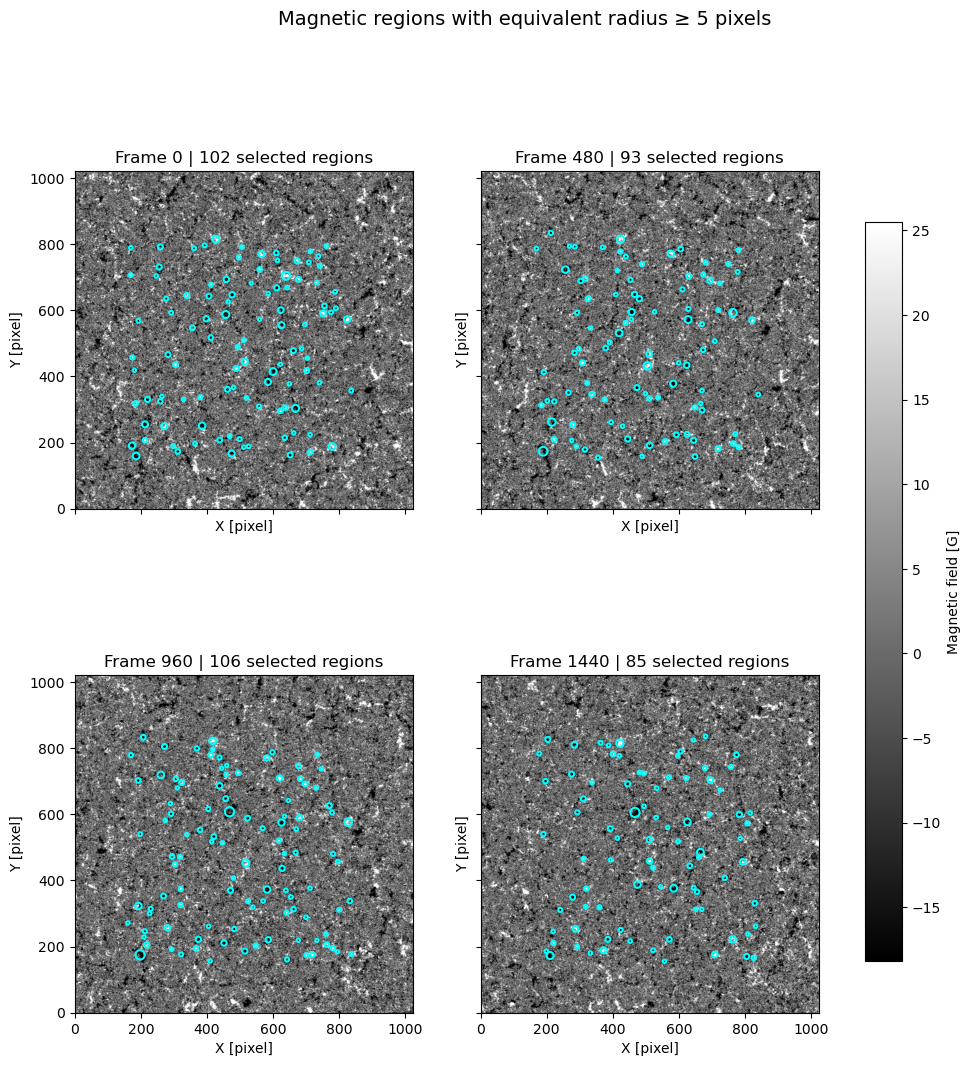

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# REFERENCE MAGNETOGRAMS + SELECTED MAGNETIC REGIONS
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 12),
    sharex=True,
    sharey=True
)

# ------------------------------------------------------------
# Common color scale for all reference magnetograms
# ------------------------------------------------------------

all_values = np.concatenate([
    ref["magnetogram"][np.isfinite(ref["magnetogram"])].ravel()
    for ref in magnetograms_of_reference
])

vmin, vmax = np.percentile(all_values, [5, 98])

# ------------------------------------------------------------
# Plot each reference magnetogram
# ------------------------------------------------------------

for ax, ref in zip(axes.flat, magnetograms_of_reference):

    mag_frame = ref["magnetogram"]
    selected_regions = ref["selected_regions"]

    # Magnetogram
    im = ax.imshow(
        mag_frame,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    # Draw equivalent circles of the selected regions
    for region in selected_regions:

        circle = Circle(
            (region["x_center"], region["y_center"]),
            region["r_equivalent_pixels"],
            fill=False,
            linewidth=1.5,
            color="cyan"
        )

        ax.add_patch(circle)

    # Panel format
    ax.set_title(
        f'Frame {ref["frame"]} | '
        f'{len(selected_regions)} selected regions'
    )

    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")

# ------------------------------------------------------------
# Common colorbar
# ------------------------------------------------------------

fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    label="Magnetic field [G]",
    shrink=0.8
)

fig.suptitle(
    "Magnetic regions with equivalent radius ≥ 5 pixels",
    #f"Magnetic regions with equivalent radius ≥ {min_radius} pixels",
    fontsize=14
)

plt.show()

# Tracking Pores Across Magnetogram Frames

Since some detected pores may persist across multiple frames of the magnetogram cube, although their positions and magnetic properties may change over time, we propose a basic algorithm to identify corresponding pores between consecutive frames, link their detections, and track their trajectories and magnetic-field evolution.

The algorithm consists of the following steps:

1. **Compute centroid distances:** Calculate the Euclidean distance between the centroids of detected regions in different frames.
2. **Identify matching pores:** Introduce a `"same_pores"` key to associate regions whose centroid separation satisfies the following threshold criterion:

   $$
   d_{\mathrm{centroid}} < d_{\mathrm{th}}, \qquad
   d_{\mathrm{th}} = \alpha r_{\mathrm{eq}} + \frac{\Delta \mathrm{frame}}{10}
   $$

3. **Update the pore position:** Define the updated pore center as the midpoint between the centroids of the matched regions.
4. **Update the equivalent radius:** Assign the average equivalent radius of the two matched regions.
5. **Visualize pore evolution:** Draw arrows representing the displacement vectors between matched regions, with arrow widths proportional to the change in mean magnetic-field strength.

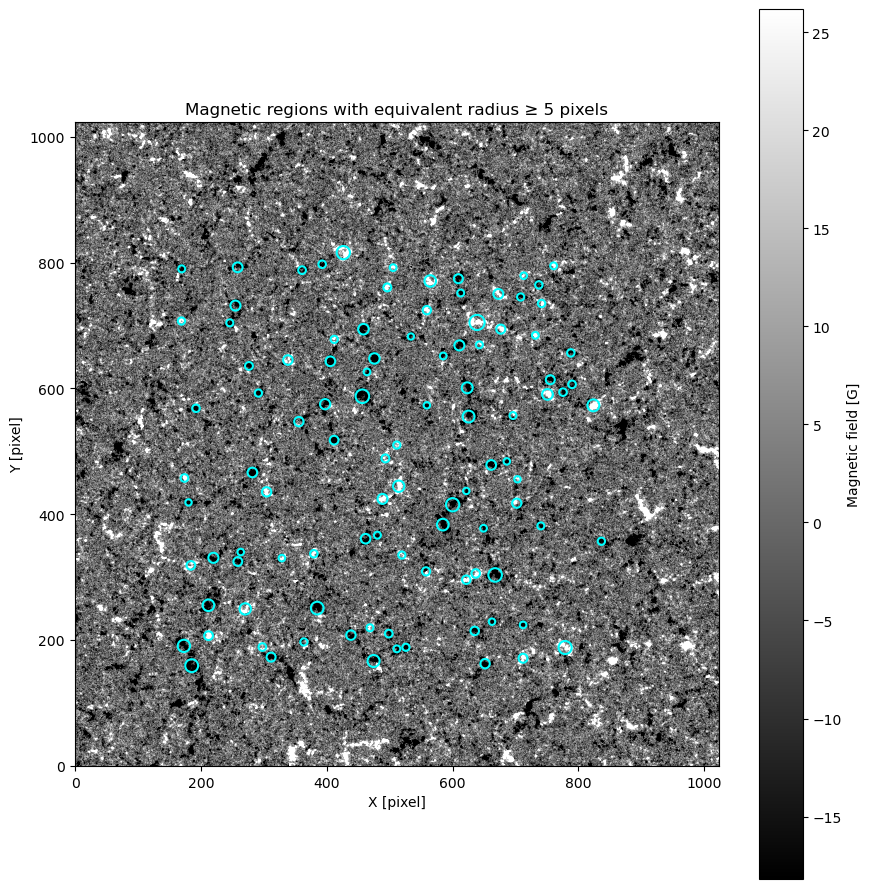

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# MAGNETOGRAMA + CÍRCULOS DE ÁREA EQUIVALENTE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# Magnetograma
im = ax.imshow(
    mag_frame,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(mag_frame,5),
    vmax=np.percentile(mag_frame,98)
)

# ------------------------------------------------------------
# Dibujar círculos de las regiones seleccionadas
# ------------------------------------------------------------

for region in selected_regions:

    circle = Circle(
        (region["x_center"], region["y_center"]),
        region["r_equivalent_pixels"],
        fill=False,
        linewidth=1.5,
        color='cyan'
    )

    ax.add_patch(circle)

# ------------------------------------------------------------
# Formato
# ------------------------------------------------------------

plt.colorbar(
    im,
    ax=ax,
    label="Magnetic field [G]"
)

ax.set_xlabel("X [pixel]")
ax.set_ylabel("Y [pixel]")

ax.set_title(
    f"Magnetic regions with equivalent radius ≥ {min_radius} pixels"
)

plt.tight_layout()
plt.show()

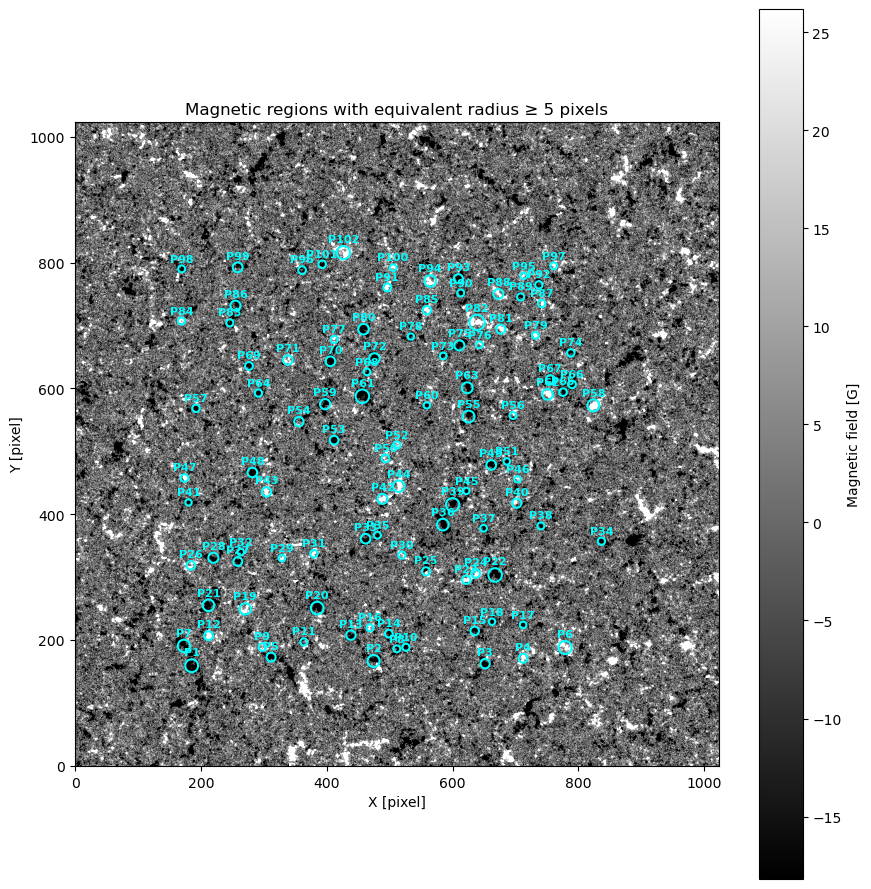

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

# ============================================================
# ASIGNAR UN ID A CADA PORO
# ============================================================

for i, region in enumerate(selected_regions, start=1):
    region["pore_id"] = f"P{i}"


# ============================================================
# MAGNETOGRAMA + CÍRCULOS + IDs
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# Magnetograma
im = ax.imshow(
    mag_frame,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(mag_frame, 5),
    vmax=np.percentile(mag_frame, 98)
)


# ============================================================
# DIBUJAR CÍRCULOS E IDENTIFICADORES
# ============================================================

for region in selected_regions:

    x0 = region["x_center"]
    y0 = region["y_center"]
    r  = region["r_equivalent_pixels"]

    # Círculo equivalente
    circle = Circle(
        (x0, y0),
        r,
        fill=False,
        linewidth=1.5,
        color="cyan"
    )

    ax.add_patch(circle)

    # Número/ID del poro
    ax.text(
        x0,
        y0 + r + 3,
        region["pore_id"],
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="cyan"
    )


# ============================================================
# FORMATO
# ============================================================

plt.colorbar(
    im,
    ax=ax,
    label="Magnetic field [G]"
)

ax.set_xlabel("X [pixel]")
ax.set_ylabel("Y [pixel]")

ax.set_title(
    f"Magnetic regions with equivalent radius ≥ {min_radius} pixels"
)

plt.tight_layout()
plt.show()

## Chose the 5 strongest pores

In [8]:
# ============================================================
# CAMPO MAGNÉTICO MEDIO DENTRO DE CADA CÍRCULO
# ============================================================

ny, nx = mag_frame.shape
yy, xx = np.mgrid[0:ny, 0:nx]

for region in selected_regions:

    x0 = region["x_center"]
    y0 = region["y_center"]
    r  = region["r_equivalent_pixels"]

    # Máscara circular
    circle_mask = (
        (xx - x0)**2 +
        (yy - y0)**2
        <= r**2
    )

    # Valores dentro del círculo
    values = mag_frame[circle_mask]

    # Campo absoluto medio
    region["mean_abs_B"] = np.nanmean(np.abs(values))


# ============================================================
# SELECCIONAR LOS 5 MÁS INTENSOS
# ============================================================

top10_pores = sorted(
    selected_regions,
    key=lambda region: region["mean_abs_B"],
    reverse=True
)[:10]


# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print("Top 10 pores by mean |B|:\n")

for region in top10_pores:

    print(
        f"{region['pore_id']}: "
        f"<|B|> = {region['mean_abs_B']:.2f} G, "
        f"center = ({region['x_center']:.2f}, "
        f"{region['y_center']:.2f}), "
        f"r_eq = {region['r_equivalent_pixels']:.2f} pix"
    )

Top 10 pores by mean |B|:

P72: <|B|> = 80.31 G, center = (475.81, 647.51), r_eq = 8.31 pix
P70: <|B|> = 78.41 G, center = (405.81, 642.99), r_eq = 7.69 pix
P58: <|B|> = 67.93 G, center = (823.85, 572.94), r_eq = 9.46 pix
P24: <|B|> = 65.70 G, center = (636.90, 305.74), r_eq = 6.77 pix
P3: <|B|> = 58.75 G, center = (651.71, 162.30), r_eq = 7.46 pix
P12: <|B|> = 58.10 G, center = (212.10, 206.81), r_eq = 6.98 pix
P5: <|B|> = 50.88 G, center = (311.53, 172.74), r_eq = 7.20 pix
P69: <|B|> = 50.71 G, center = (276.41, 635.59), r_eq = 6.26 pix
P44: <|B|> = 50.41 G, center = (514.42, 444.35), r_eq = 9.01 pix
P91: <|B|> = 47.80 G, center = (496.29, 760.42), r_eq = 6.28 pix


Selected pores:
P72: <|B|> = 80.31 G, r_eq = 8.31 pix
P70: <|B|> = 78.41 G, r_eq = 7.69 pix
P58: <|B|> = 67.93 G, r_eq = 9.46 pix
P24: <|B|> = 65.70 G, r_eq = 6.77 pix
P3: <|B|> = 58.75 G, r_eq = 7.46 pix
P12: <|B|> = 58.10 G, r_eq = 6.98 pix
P5: <|B|> = 50.88 G, r_eq = 7.20 pix
P69: <|B|> = 50.71 G, r_eq = 6.26 pix
P44: <|B|> = 50.41 G, r_eq = 9.01 pix
P91: <|B|> = 47.80 G, r_eq = 6.28 pix


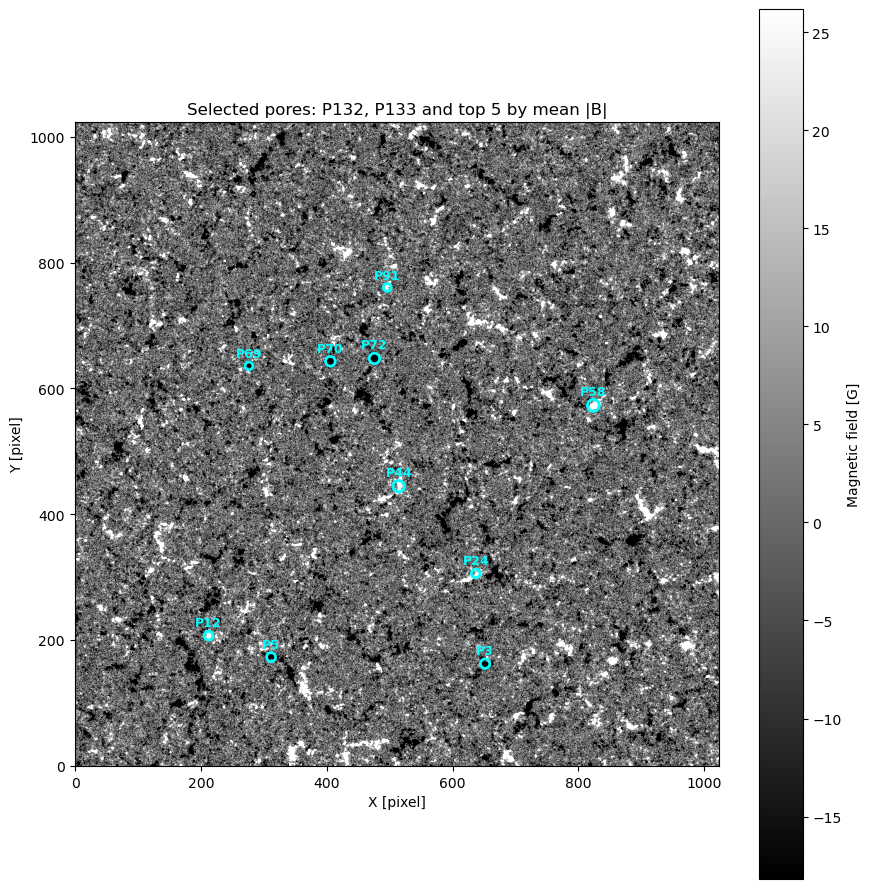

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

# ============================================================
# 1. SELECCIONAR P132 Y P133
# ============================================================

manual_ids = ["P132", "P133"]

manual_pores = [
    region for region in selected_regions
    if region["pore_id"] in manual_ids
]


# ============================================================
# 2. COMBINAR CON LOS 5 POROS MÁS FUERTES
# ============================================================

pores_to_plot = top10_pores + manual_pores

# Evitar duplicados por si P132 o P133 ya está en el top 5
pores_to_plot = list({
    region["pore_id"]: region
    for region in pores_to_plot
}.values())

print("Selected pores:")
for region in pores_to_plot:
    print(
        f"{region['pore_id']}: "
        f"<|B|> = {region['mean_abs_B']:.2f} G, "
        f"r_eq = {region['r_equivalent_pixels']:.2f} pix"
    )


# ============================================================
# 3. GRAFICAR MAGNETOGRAMA
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

im = ax.imshow(
    mag_frame,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(mag_frame, 5),
    vmax=np.percentile(mag_frame, 98)
)


# ============================================================
# 4. GRAFICAR LOS POROS SELECCIONADOS
# ============================================================

for region in pores_to_plot:

    x0 = region["x_center"]
    y0 = region["y_center"]
    r = region["r_equivalent_pixels"]

    circle = Circle(
        (x0, y0),
        r,
        fill=False,
        linewidth=2,
        color="cyan"
    )

    ax.add_patch(circle)

    ax.text(
        x0,
        y0 + r + 3,
        region["pore_id"],
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="cyan"
    )


# ============================================================
# 5. FORMATO
# ============================================================

plt.colorbar(
    im,
    ax=ax,
    label="Magnetic field [G]"
)

ax.set_xlabel("X [pixel]")
ax.set_ylabel("Y [pixel]")

ax.set_title(
    "Selected pores: P132, P133 and top 5 by mean |B|"
)

plt.tight_layout()
plt.show()

In [10]:
import os
import numpy as np

# ============================================================
# GUARDAR LOS POROS SELECCIONADOS (pores_to_plot) EN UN .npz
# ============================================================
# Geometría definida en el primer frame (t = 0). El archivo se
# puede reutilizar para construir máscaras o dibujar los poros
# sobre cualquier otro mapa con la misma geometría (1024 x 1024).

pores_npz = "../data/2018_08_25/pores/selected_pores_MAG_24_frame0.npz"
os.makedirs(os.path.dirname(pores_npz), exist_ok=True)

ny, nx = mag_frame.shape
yy, xx = np.mgrid[0:ny, 0:nx]

n_sel = len(pores_to_plot)

circle_masks   = np.zeros((n_sel, ny, nx), dtype=bool)   # círculo de radio equivalente
region_masks   = np.zeros((n_sel, ny, nx), dtype=bool)   # región conexa exacta (|B| > p80)
pore_label_map = np.zeros((ny, nx), dtype=np.int16)      # 0 = fondo, k = poro k (1..n)

for k, region in enumerate(pores_to_plot):

    circle = (
        (xx - region["x_center"])**2 +
        (yy - region["y_center"])**2
        <= region["r_equivalent_pixels"]**2
    )

    circle_masks[k] = circle
    region_masks[k] = labeled_regions == region["label"]

    # Si dos círculos se solapan, conserva el primero que ocupó el píxel
    pore_label_map[circle & (pore_label_map == 0)] = k + 1

np.savez_compressed(
    pores_npz,
    # --- identificación ---
    pore_id        = np.array([r["pore_id"] for r in pores_to_plot]),
    region_label   = np.array([r["label"] for r in pores_to_plot], dtype=np.int32),
    is_manual      = np.array([r["pore_id"] in manual_ids for r in pores_to_plot]),
    # --- geometría (píxeles, origen en el píxel [0, 0]) ---
    x_center       = np.array([r["x_center"] for r in pores_to_plot], dtype=np.float64),
    y_center       = np.array([r["y_center"] for r in pores_to_plot], dtype=np.float64),
    r_eq           = np.array([r["r_equivalent_pixels"] for r in pores_to_plot], dtype=np.float64),
    area_pixels    = np.array([r["area_pixels"] for r in pores_to_plot], dtype=np.int32),
    mean_abs_B     = np.array([r["mean_abs_B"] for r in pores_to_plot], dtype=np.float64),
    # --- máscaras ---
    circle_masks   = circle_masks,
    region_masks   = region_masks,
    pore_label_map = pore_label_map,
    # --- metadatos ---
    threshold_p80  = np.float64(p80),
    frame_index    = np.int32(0),
    frame_shape    = np.array([ny, nx], dtype=np.int32),
    source_cube    = np.array(MAG_cube),
    fits_header    = np.array(header.tostring(sep="\n")),
)

print(f"Guardados {n_sel} poros en: {pores_npz}")
for r in pores_to_plot:
    print(f"  {r['pore_id']:>5s}  center = ({r['x_center']:.2f}, {r['y_center']:.2f})  "
          f"r_eq = {r['r_equivalent_pixels']:.2f} pix  <|B|> = {r['mean_abs_B']:.2f} G")

Guardados 10 poros en: ../data/2018_08_25/pores/selected_pores_MAG_24_frame0.npz
    P72  center = (475.81, 647.51)  r_eq = 8.31 pix  <|B|> = 80.31 G
    P70  center = (405.81, 642.99)  r_eq = 7.69 pix  <|B|> = 78.41 G
    P58  center = (823.85, 572.94)  r_eq = 9.46 pix  <|B|> = 67.93 G
    P24  center = (636.90, 305.74)  r_eq = 6.77 pix  <|B|> = 65.70 G
     P3  center = (651.71, 162.30)  r_eq = 7.46 pix  <|B|> = 58.75 G
    P12  center = (212.10, 206.81)  r_eq = 6.98 pix  <|B|> = 58.10 G
     P5  center = (311.53, 172.74)  r_eq = 7.20 pix  <|B|> = 50.88 G
    P69  center = (276.41, 635.59)  r_eq = 6.26 pix  <|B|> = 50.71 G
    P44  center = (514.42, 444.35)  r_eq = 9.01 pix  <|B|> = 50.41 G
    P91  center = (496.29, 760.42)  r_eq = 6.28 pix  <|B|> = 47.80 G


 [astropy.io.fits.verify]


Cube shape: (1920, 1024, 1024) | dtype: >i8 | BSCALE: 1e-16 | BZERO: 0.0 | BLANK: None
Máx. diferencia frame 0 vs mag_frame [G]: 0.0
Processed 200/1920 frames (10.4%)
Processed 400/1920 frames (20.8%)
Processed 600/1920 frames (31.2%)
Processed 800/1920 frames (41.7%)
Processed 1000/1920 frames (52.1%)
Processed 1200/1920 frames (62.5%)
Processed 1400/1920 frames (72.9%)
Processed 1600/1920 frames (83.3%)
Processed 1800/1920 frames (93.8%)
Processed 1920/1920 frames (100.0%)

Umbral |B| > 13.19 G  |  presencia si f_t >= 50%


,Pore,x_center,y_center,r_eq (pix),Valid frames,Frames present,Persistence (%),Area > thr (%),|B|-weighted area (%),<|B|> t0 (G),<|B|> day (G),<|B|> above thr (G),Intensity index (G),Score (%)
0,P58,823.85,572.94,9.46,1920,1064,55.42,44.44,75.05,67.93,33.08,50.18,30.28,100.00
1,P44,514.42,444.35,9.01,1920,440,22.92,42.46,84.50,50.41,23.50,42.68,20.53,67.81
2,P72,475.81,647.51,8.31,1920,459,23.91,30.97,61.92,80.31,21.78,36.91,18.29,60.41
3,P3,651.71,162.30,7.46,1920,447,23.28,32.91,68.19,58.75,21.61,40.10,18.21,60.16
4,P12,212.10,206.81,6.98,1920,296,15.42,31.19,68.50,58.10,18.78,37.34,15.29,50.51
5,P24,636.90,305.74,6.77,1920,628,32.71,39.40,76.05,65.70,18.13,32.06,14.99,49.50
6,P70,405.81,642.99,7.69,1920,414,21.56,28.21,57.12,78.41,18.40,32.69,14.79,48.86
7,P69,276.41,635.59,6.26,1920,435,22.66,30.03,62.03,50.71,15.99,30.19,12.44,41.09
8,P5,311.53,172.74,7.20,1920,288,15.00,27.56,61.14,50.88,14.28,28.95,10.62,35.08
9,P91,496.29,760.42,6.28,1920,167,8.70,23.22,52.51,47.80,10.55,21.89,6.65,21.97


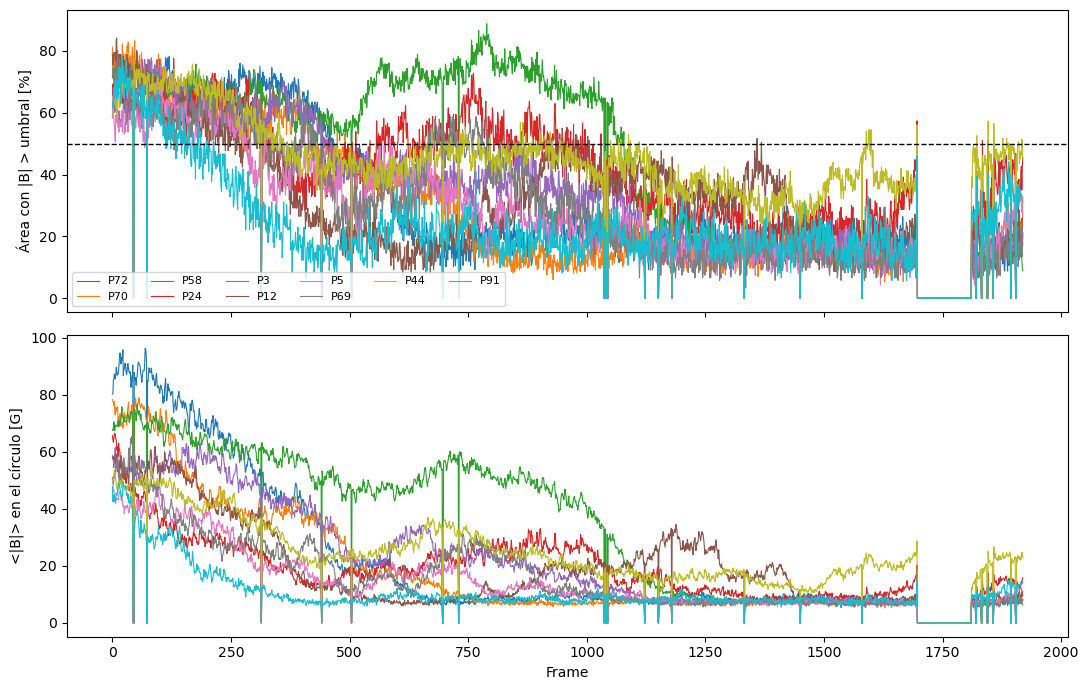

In [11]:
from astropy.io import fits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MAG_cube = "../data/2018_08_25/cubes/MAG_24.fits"

# ============================================================
# 1. PARÁMETROS
# ============================================================

pores_to_study = pores_to_plot

# Umbral de referencia: p80 de |B| en el primer frame (en Gauss)
B_threshold = p80

# Un poro está "presente" en un frame si al menos esta fracción
# de los píxeles de su círculo supera el umbral
presence_fraction_threshold = 0.50

# Un frame solo cuenta para un poro si al menos esta fracción
# de sus píxeles es finita (evita frames vacíos / NaN)
min_finite_fraction = 0.90

n_pores = len(pores_to_study)


# ============================================================
# 2. ABRIR EL CUBO (memmap, sin escalar todo el cubo)
# ============================================================
# IMPORTANTE: con do_not_scale_image_data=True los datos vienen
# en unidades "crudas". Hay que aplicar  B = raw * BSCALE + BZERO
# para que sean comparables con p80 (que está en Gauss).
# En la versión anterior esto no se hacía (BSCALE = 1e-16), así que
# TODOS los píxeles superaban el umbral y todos los poros daban
# el mismo porcentaje (solo cambiaban los frames con NaN).

with fits.open(MAG_cube, memmap=True, do_not_scale_image_data=True) as hdul:

    cube_raw = hdul[0].data
    hdr      = hdul[0].header

    bscale = hdr.get("BSCALE", 1.0)
    bzero  = hdr.get("BZERO", 0.0)
    blank  = hdr.get("BLANK", None) if np.issubdtype(cube_raw.dtype, np.integer) else None

    n_frames, ny, nx = cube_raw.shape
    print("Cube shape:", cube_raw.shape, "| dtype:", cube_raw.dtype,
          "| BSCALE:", bscale, "| BZERO:", bzero, "| BLANK:", blank)

    # ========================================================
    # 3. PÍXELES DE CADA PORO (fijos, definidos en el frame 0)
    # ========================================================
    # Se concatenan todos los píxeles de los 12 poros en un solo
    # vector para leer cada frame con un único acceso al memmap.

    all_y, all_x, owner = [], [], []

    for i, region in enumerate(pores_to_study):

        x0, y0, r = region["x_center"], region["y_center"], region["r_equivalent_pixels"]

        x_min = max(0, int(np.floor(x0 - r)));  x_max = min(nx, int(np.ceil(x0 + r)) + 1)
        y_min = max(0, int(np.floor(y0 - r)));  y_max = min(ny, int(np.ceil(y0 + r)) + 1)

        yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
        circle = (xx - x0)**2 + (yy - y0)**2 <= r**2

        all_y.append(yy[circle])
        all_x.append(xx[circle])
        owner.append(np.full(circle.sum(), i))

    all_y = np.concatenate(all_y)
    all_x = np.concatenate(all_x)
    owner = np.concatenate(owner)

    n_pix = np.bincount(owner, minlength=n_pores)

    # Chequeo: el frame 0 escalado debe coincidir con mag_frame
    check = cube_raw[0, all_y, all_x].astype(np.float64) * bscale + bzero
    ref   = mag_frame[all_y, all_x].astype(np.float64)
    ok    = np.isfinite(check) & np.isfinite(ref)
    print("Máx. diferencia frame 0 vs mag_frame [G]:",
          np.max(np.abs(check[ok] - ref[ok])) if ok.any() else "sin datos")

    # ========================================================
    # 4. SERIES TEMPORALES POR PORO
    # ========================================================

    area_fraction   = np.full((n_pores, n_frames), np.nan)  # f_t   : fracción de píxeles con |B| > umbral
    flux_fraction   = np.full((n_pores, n_frames), np.nan)  # fw_t  : fracción de Σ|B| aportada por esos píxeles
    mean_absB       = np.full((n_pores, n_frames), np.nan)  # <|B|> en el círculo [G]
    mean_absB_above = np.full((n_pores, n_frames), np.nan)  # <|B|> solo de píxeles sobre el umbral [G]
    flux_density    = np.full((n_pores, n_frames), np.nan)  # Σ|B|·H(|B|-umbral) / N_pix  [G]

    for t in range(n_frames):

        raw  = cube_raw[t, all_y, all_x]
        vals = raw.astype(np.float64)

        if blank is not None:
            vals[raw == blank] = np.nan

        absB   = np.abs(vals * bscale + bzero)
        finite = np.isfinite(absB)
        above  = finite & (absB > B_threshold)
        absB0  = np.where(finite, absB, 0.0)

        n_fin     = np.bincount(owner, weights=finite,        minlength=n_pores)
        n_above   = np.bincount(owner, weights=above,         minlength=n_pores)
        sum_B     = np.bincount(owner, weights=absB0,         minlength=n_pores)
        sum_Babov = np.bincount(owner, weights=absB0 * above, minlength=n_pores)

        valid = n_fin >= min_finite_fraction * n_pix

        with np.errstate(invalid="ignore", divide="ignore"):
            area_fraction[valid, t]   = (n_above   / n_fin)[valid]
            flux_fraction[valid, t]   = (sum_Babov / sum_B)[valid]
            mean_absB[valid, t]       = (sum_B     / n_fin)[valid]
            mean_absB_above[valid, t] = np.where(n_above > 0, sum_Babov / n_above, 0.0)[valid]
            flux_density[valid, t]    = (sum_Babov / n_fin)[valid]

        if (t + 1) % 200 == 0 or t == n_frames - 1:
            print(f"Processed {t + 1}/{n_frames} frames ({100*(t+1)/n_frames:.1f}%)")


# ============================================================
# 5. MÉTRICAS DE PERSISTENCIA
# ============================================================
#  - Persistence (%)          : % de frames válidos con f_t >= 50 %
#  - Area > thr (%)           : promedio temporal de f_t
#  - |B|-weighted area > thr  : promedio temporal de fw_t
#                               (cada píxel pesa según su |B|)
#  - Intensity index [G]      : promedio temporal de Σ|B|·H(|B|-thr)/N_pix
#                               -> combina ÁREA sobre el umbral e INTENSIDAD
#  - Score (%)                : Intensity index normalizado al mejor poro
#                               (criterio de ordenamiento final)

valid_frames = np.isfinite(area_fraction)
presence     = (area_fraction >= presence_fraction_threshold) & valid_frames

results = []

for i, region in enumerate(pores_to_study):

    v  = valid_frames[i]
    nv = v.sum()

    results.append({
        "Pore":                    region["pore_id"],
        "x_center":                region["x_center"],
        "y_center":                region["y_center"],
        "r_eq (pix)":              region["r_equivalent_pixels"],
        "Valid frames":            int(nv),
        "Frames present":          int(presence[i].sum()),
        "Persistence (%)":         100 * presence[i].sum() / nv if nv else np.nan,
        "Area > thr (%)":          100 * np.nanmean(area_fraction[i]),
        "|B|-weighted area (%)":   100 * np.nanmean(flux_fraction[i]),
        "<|B|> t0 (G)":            region["mean_abs_B"],
        "<|B|> day (G)":           np.nanmean(mean_absB[i]),
        "<|B|> above thr (G)":     np.nanmean(mean_absB_above[i]),
        "Intensity index (G)":     np.nanmean(flux_density[i]),
    })

persistence_df = pd.DataFrame(results)
persistence_df["Score (%)"] = (
    100 * persistence_df["Intensity index (G)"] / persistence_df["Intensity index (G)"].max()
)

persistence_df = persistence_df.sort_values("Score (%)", ascending=False).reset_index(drop=True)

print(f"\nUmbral |B| > {B_threshold:.2f} G  |  presencia si f_t >= {presence_fraction_threshold:.0%}")

# Opcional: guardar la tabla
# persistence_df.to_csv("../data/2018_08_25/pores/pores_persistence_MAG_24.csv", index=False)

display(persistence_df.round(2))


# ============================================================
# 6. CONTROL VISUAL: FRACCIÓN SOBRE EL UMBRAL VS TIEMPO
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for i, region in enumerate(pores_to_study):
    axes[0].plot(100 * area_fraction[i], lw=0.8, label=region["pore_id"])
    axes[1].plot(mean_absB[i],           lw=0.8, label=region["pore_id"])

axes[0].axhline(100 * presence_fraction_threshold, color="k", ls="--", lw=1)
axes[0].set_ylabel("Área con |B| > umbral [%]")
axes[1].set_ylabel("<|B|> en el círculo [G]")
axes[1].set_xlabel("Frame")
axes[0].legend(ncol=6, fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

In [12]:
import os
import numpy as np

# ============================================================
# REGIONES ORDENADAS POR SCORE -> R01, R02, ... + GUARDAR .npz
# ============================================================
# Requiere haber corrido la celda de persistencia
# (persistence_df, pores_to_study, mean_absB, area_fraction, ...)

ranked_npz = "../data/2018_08_25/pores/ranked_regions_MAG_24.npz"
os.makedirs(os.path.dirname(ranked_npz), exist_ok=True)

# ------------------------------------------------------------
# 1. ORDEN POR SCORE Y NUEVOS NOMBRES
# ------------------------------------------------------------

ranked_df = persistence_df.sort_values("Score (%)", ascending=False).reset_index(drop=True)

id_to_idx = {r["pore_id"]: i for i, r in enumerate(pores_to_study)}
order     = np.array([id_to_idx[p] for p in ranked_df["Pore"]])   # índice original de cada rank

n_reg      = len(order)
rank_names = np.array([f"R{k+1:02d}" for k in range(n_reg)])      # R01 = mejor score
ranked_df.insert(0, "Region", rank_names)
ranked_df.insert(1, "Rank", np.arange(1, n_reg + 1))

# ------------------------------------------------------------
# 2. MÁSCARAS EN EL ORDEN DEL RANKING
# ------------------------------------------------------------

ny, nx = mag_frame.shape
yy, xx = np.mgrid[0:ny, 0:nx]

circle_masks   = np.zeros((n_reg, ny, nx), dtype=bool)
region_masks   = np.zeros((n_reg, ny, nx), dtype=bool)
rank_label_map = np.zeros((ny, nx), dtype=np.int16)   # 0 = fondo, k = región R{k}

for k, i in enumerate(order):
    reg = pores_to_study[i]
    circ = (xx - reg["x_center"])**2 + (yy - reg["y_center"])**2 <= reg["r_equivalent_pixels"]**2
    circle_masks[k] = circ
    region_masks[k] = labeled_regions == reg["label"]
    rank_label_map[circ & (rank_label_map == 0)] = k + 1

# ------------------------------------------------------------
# 3. CAMPO MAGNÉTICO MEDIO (recompilado)
# ------------------------------------------------------------

B_t0_signed = np.array([np.nanmean(mag_frame[circle_masks[k]])         for k in range(n_reg)])
B_t0_abs    = np.array([np.nanmean(np.abs(mag_frame[circle_masks[k]])) for k in range(n_reg)])

absB_series = mean_absB[order]                       # (n_reg, n_frames) <|B|>(t) de cada región
B_day_abs   = np.nanmean(absB_series, axis=1)        # <|B|> promedio del día
B_day_std   = np.nanstd(absB_series, axis=1)         # variabilidad temporal
B_day_med   = np.nanmedian(absB_series, axis=1)

polarity = np.sign(B_t0_signed).astype(np.int8)      # +1 / -1

# Orden por intensidad magnética (de mayor a menor <|B|> del día),
# expresado como índices sobre el arreglo ya ordenado por score
order_by_B = np.argsort(-B_day_abs)

ranked_df["<B> t0 signed (G)"] = B_t0_signed
ranked_df["<|B|> t0 (G)"]      = B_t0_abs
ranked_df["<|B|> day (G)"]     = B_day_abs
ranked_df["std |B| day (G)"]   = B_day_std
ranked_df["Polarity"]          = polarity
ranked_df["Rank by |B|"]       = np.argsort(order_by_B) + 1

# ------------------------------------------------------------
# 4. GUARDAR
# ------------------------------------------------------------

np.savez_compressed(
    ranked_npz,
    # identificación (todo en orden de score: índice 0 = R01)
    region_name        = rank_names,
    rank               = np.arange(1, n_reg + 1, dtype=np.int32),
    original_pore_id   = ranked_df["Pore"].to_numpy().astype(str),
    # geometría
    x_center           = ranked_df["x_center"].to_numpy(float),
    y_center           = ranked_df["y_center"].to_numpy(float),
    r_eq               = ranked_df["r_eq (pix)"].to_numpy(float),
    circle_masks       = circle_masks,
    region_masks       = region_masks,
    rank_label_map     = rank_label_map,
    # campo magnético
    B_t0_signed        = B_t0_signed,
    B_t0_abs           = B_t0_abs,
    B_day_abs          = B_day_abs,
    B_day_std          = B_day_std,
    B_day_median       = B_day_med,
    polarity           = polarity,
    absB_series        = absB_series.astype(np.float32),
    area_fraction_series = (area_fraction[order]).astype(np.float32),
    order_by_B         = order_by_B.astype(np.int32),
    # persistencia
    score              = ranked_df["Score (%)"].to_numpy(float),
    intensity_index    = ranked_df["Intensity index (G)"].to_numpy(float),
    persistence        = ranked_df["Persistence (%)"].to_numpy(float),
    area_above_thr     = ranked_df["Area > thr (%)"].to_numpy(float),
    # metadatos
    threshold_B        = np.float64(B_threshold),
    frame_shape        = np.array([ny, nx], dtype=np.int32),
    source_cube        = np.array(MAG_cube),
)

print(f"Guardado: {ranked_npz}\n")
display(ranked_df[["Region", "Pore", "Score (%)", "Persistence (%)",
                   "<|B|> day (G)", "std |B| day (G)", "<B> t0 signed (G)",
                   "Polarity", "Rank by |B|"]].round(2))

Guardado: ../data/2018_08_25/pores/ranked_regions_MAG_24.npz



,Region,Pore,Score (%),Persistence (%),<|B|> day (G),std |B| day (G),<B> t0 signed (G),Polarity,Rank by |B|
0,R01,P58,100.00,55.42,33.08,24.57,65.61,1,1
1,R02,P44,67.81,22.92,23.50,12.02,48.83,1,2
2,R03,P72,60.41,23.91,21.78,25.38,-78.82,-1,3
3,R04,P3,60.16,23.28,21.61,17.92,-57.63,-1,4
4,R05,P12,50.51,15.42,18.78,15.10,57.09,1,5
5,R06,P24,49.50,32.71,18.13,11.02,64.85,1,7
6,R07,P70,48.86,21.56,18.40,19.72,-77.54,-1,6
7,R08,P69,41.09,22.66,15.99,12.86,-50.43,-1,8
8,R09,P5,35.08,15.00,14.28,11.02,-49.49,-1,9
9,R10,P91,21.97,8.70,10.55,8.18,46.84,1,10
